# GSAT Explainer for BA2Motif (BCOS GIN)
This notebook implements a GSAT-style explainer for the BA2Motif dataset using a BCOS GIN backbone (no edge attributes). It follows the GSAT structure from `GSAT_di_halo_benzene.ipynb` and the BA2Motif data setup pattern from `IG_BA2Motif.ipynb`.

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import degree

# -------------------------
# Repro / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

# -------------------------
# Ensure repo root on sys.path (so `import bcosgnn` works)
# -------------------------
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "bcosgnn").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (pyproject.toml + bcosgnn/).")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
print("Repo root added:", repo_root)

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu
Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
# -------------------------
# Load custom BA2Motif dataset list
# -------------------------
RAW_DATA_PATH = "/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt"
assert os.path.exists(RAW_DATA_PATH), f"Missing file: {RAW_DATA_PATH}"
print("Loading:", RAW_DATA_PATH)

# Enforce loading to CPU
dataset_list = torch.load(RAW_DATA_PATH, map_location="cpu", weights_only=False)
print("Graphs loaded:", len(dataset_list))
assert isinstance(dataset_list, (list, tuple)) and len(dataset_list) > 0

# If labels are missing, assign first half=0, second half=1
for i, data in enumerate(dataset_list):
    data = data.cpu()
    dataset_list[i] = data

    if not hasattr(data, "y") or data.y is None or data.y.numel() == 0:
        data.y = torch.tensor([0 if i < (len(dataset_list) // 2) else 1], dtype=torch.long)
    else:
        data.y = data.y.view(-1).to(torch.long)
        if data.y.numel() == 1:
            data.y = data.y.view(1)
        else:
            data.y = data.y[:1]

# Build node features from (clamped) degree one-hot

def add_degree_onehot_x(data: Data, max_degree: int = 4) -> Data:
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long).clamp(max=max_degree)
    data.x = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(torch.float)
    return data

for i in range(len(dataset_list)):
    dataset_list[i] = add_degree_onehot_x(dataset_list[i])
    if hasattr(dataset_list[i], "edge_attr"):
        del dataset_list[i].edge_attr

# Basic dataset stats
ys = torch.cat([d.y for d in dataset_list]).view(-1)
num_classes = int(torch.unique(ys).numel())
in_dim = int(dataset_list[0].x.size(-1))

print("num_classes =", num_classes)
print("node feature dim =", in_dim)
print("edge feature dim = N/A (BA2Motif)")

Loading: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Graphs loaded: 1000
num_classes = 2
node feature dim = 5
edge feature dim = N/A (BA2Motif)
num_classes = 2
node feature dim = 5
edge feature dim = N/A (BA2Motif)


In [3]:
from torch_geometric.nn import MessagePassing, global_add_pool
from bcos.modules import BcosLinear, BcosSequential

# -------------------------
# BCOS GIN Backbone (Maskable)
# -------------------------
class MaskableBcosGINConv(MessagePassing):
    def __init__(self, channels: list[int], b=2.0, max_out=1, eps=0.0, train_eps=False):
        super().__init__(aggr="add")
        self.transform = BcosSequential(
            *[BcosLinear(din, dout, b=b, max_out=max_out) for din, dout in zip(channels[:-1], channels[1:])]
        )
        if train_eps:
            self.eps = nn.Parameter(torch.tensor([eps], dtype=torch.float))
        else:
            self.register_buffer("eps", torch.tensor([eps], dtype=torch.float))

    def forward(self, x, edge_index, edge_weight=None):
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight)
        out = (1 + self.eps) * x + out
        return self.transform(out)

    def message(self, x_j, edge_weight=None):
        msg = x_j
        if edge_weight is not None:
            msg = msg * edge_weight.view(-1, 1)
        return msg


class BcosGINBackbone(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, num_classes: int, b=2.0, max_out=1, drop_ratio=0.5):
        super().__init__()
        self.node_proj = BcosLinear(in_dim, hidden_dim, b=b, max_out=max_out)
        self.conv1 = MaskableBcosGINConv([hidden_dim, hidden_dim], b=b, max_out=max_out, train_eps=True)
        self.conv2 = MaskableBcosGINConv([hidden_dim, hidden_dim], b=b, max_out=max_out, train_eps=True)
        self.drop_ratio = drop_ratio
        self.classifier = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)

    def forward(self, x, edge_index, edge_weight=None, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = self.node_proj(x.float())
        x = F.relu(self.conv1(x, edge_index, edge_weight=edge_weight))
        x = F.relu(self.conv2(x, edge_index, edge_weight=edge_weight))
        hg = global_add_pool(x, batch)
        hg = F.dropout(hg, p=self.drop_ratio, training=self.training)
        return self.classifier(hg)


# -------------------------
# GSAT Wrapper (No Edge Attributes)
# -------------------------
class GSAT(nn.Module):
    def __init__(self, backbone, in_channels, hidden_channels, temperature=1.0):
        super().__init__()
        self.backbone = backbone
        self.temperature = temperature

        # Attention MLP: uses concatenated source/target node features
        self.att_mlp = nn.Sequential(
            nn.Linear(in_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1),
        )

        for m in self.att_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def get_mask(self, x, edge_index, training=True):
        row, col = edge_index
        edge_rep = torch.cat([x[row], x[col]], dim=-1)
        edge_logits = self.att_mlp(edge_rep).view(-1)

        if training:
            u = torch.rand_like(edge_logits)
            noise = torch.log(u + 1e-8) - torch.log(1 - u + 1e-8)
            mask = torch.sigmoid((edge_logits + noise) / self.temperature)
        else:
            mask = torch.sigmoid(edge_logits)

        return mask, edge_logits

    def forward(self, data, training=True):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        mask, mask_logits = self.get_mask(x, edge_index, training=training)
        pred_logits = self.backbone(x, edge_index, edge_weight=mask, batch=batch)
        return pred_logits, mask, mask_logits

In [4]:
# -------------------------
# GSAT Loss + Seed Helper
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    criterion = nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)

    mask_probs = torch.sigmoid(mask_logits)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    info_loss = F.binary_cross_entropy(mask_probs, prior_target, reduction="mean")

    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    return loss, pred_loss, info_loss

In [5]:
# -------------------------
# Train / Val / Test Split
# -------------------------
indices = np.arange(len(dataset_list))
np.random.shuffle(indices)

n = len(indices)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_idx = indices[:n_train]
val_idx = indices[n_train : n_train + n_val]
test_idx = indices[n_train + n_val :]

train_dataset = [dataset_list[i] for i in train_idx]
val_dataset = [dataset_list[i] for i in val_idx]
test_dataset = [dataset_list[i] for i in test_idx]

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train graphs: {len(train_dataset)} | Val graphs: {len(val_dataset)} | Test graphs: {len(test_dataset)}")

# -------------------------
# Model + Optimizer
# -------------------------
HIDDEN_DIM = 64
LR = 1e-3
EPOCHS = 100
EARLY_STOP_PATIENCE = 25
R_PRIOR = 0.7
INFO_LOSS_COEF = 3.0

backbone = BcosGINBackbone(
    in_dim=in_dim,
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
    b=2.0,
    max_out=1,
    drop_ratio=0.5,
)

model = GSAT(
    backbone=backbone,
    in_channels=in_dim,
    hidden_channels=HIDDEN_DIM,
    temperature=1.0,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Model ready.")

Train graphs: 800 | Val graphs: 100 | Test graphs: 100
Model ready.


In [6]:
# -------------------------
# Sanity Check (single batch, no training required)
# -------------------------
model.eval()
batch = next(iter(train_loader))
batch = batch.to(DEVICE)
with torch.no_grad():
    logits, mask, mask_logits = model(batch, training=False)

print("Logits shape:", logits.shape)
print("Mask shape:", mask.shape)
print("Mask logits shape:", mask_logits.shape)

Logits shape: torch.Size([128, 2])
Mask shape: torch.Size([6236])
Mask logits shape: torch.Size([6236])


In [7]:
# -------------------------
# Training Loop
# -------------------------
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()

    # Anneal temperature: 1.0 -> 0.1
    model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)

    total_loss = 0.0
    total_pred = 0.0
    total_info = 0.0

    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()

        logits, mask, mask_logits = model(batch, training=True)
        loss, pred_l, info_l = gsat_loss(
            logits,
            batch.y.view(-1).to(torch.long),
            mask_logits,
            r=R_PRIOR,
            pred_loss_coef=1.0,
            info_loss_coef=INFO_LOSS_COEF,
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_pred += pred_l.item()
        total_info += info_l.item()

    # Validation (use pred loss only for early stopping)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            logits, _, _ = model(batch, training=False)
            criterion = nn.CrossEntropyLoss()
            val_loss += criterion(logits, batch.y.view(-1).to(torch.long)).item()

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | Tau {model.temperature:.2f} | "
            f"Loss {total_loss/len(train_loader):.4f} | "
            f"Pred {total_pred/len(train_loader):.4f} | "
            f"Info {total_info/len(train_loader):.4f} | "
            f"Val {val_loss/len(val_loader):.4f}"
        )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print("Training done.")

Epoch 010 | Tau 0.91 | Loss 2.0313 | Pred 0.1817 | Info 0.6165 | Val 0.0323
Epoch 020 | Tau 0.82 | Loss 1.9397 | Pred 0.0887 | Info 0.6170 | Val 0.0030
Epoch 020 | Tau 0.82 | Loss 1.9397 | Pred 0.0887 | Info 0.6170 | Val 0.0030
Epoch 030 | Tau 0.73 | Loss 1.9445 | Pred 0.0953 | Info 0.6164 | Val 0.0018
Epoch 030 | Tau 0.73 | Loss 1.9445 | Pred 0.0953 | Info 0.6164 | Val 0.0018
Epoch 040 | Tau 0.64 | Loss 1.9283 | Pred 0.0761 | Info 0.6174 | Val 0.0007
Epoch 040 | Tau 0.64 | Loss 1.9283 | Pred 0.0761 | Info 0.6174 | Val 0.0007
Epoch 050 | Tau 0.55 | Loss 1.9783 | Pred 0.1226 | Info 0.6186 | Val 0.0007
Epoch 050 | Tau 0.55 | Loss 1.9783 | Pred 0.1226 | Info 0.6186 | Val 0.0007
Epoch 060 | Tau 0.46 | Loss 2.0107 | Pred 0.1558 | Info 0.6183 | Val 0.0043
Epoch 060 | Tau 0.46 | Loss 2.0107 | Pred 0.1558 | Info 0.6183 | Val 0.0043
Epoch 070 | Tau 0.37 | Loss 1.9802 | Pred 0.1141 | Info 0.6220 | Val 0.0028
Epoch 070 | Tau 0.37 | Loss 1.9802 | Pred 0.1141 | Info 0.6220 | Val 0.0028
Epoch 080 | 

In [8]:
# -------------------------
# Evaluation (Explain.py): Accuracy + Node AUROC + Node Jaccard
# -------------------------
from sklearn.metrics import roc_auc_score
from bcosgnn.explain import explain

class BackboneWrapper(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x, edge_index, batch):
        return self.backbone(x, edge_index, edge_weight=None, batch=batch)

model.eval()

wrapper = BackboneWrapper(model.backbone).to(DEVICE)
wrapper.eval()

node_aurocs = []
node_jaccards = []

correct_graphs = 0
total_graphs = 0

num_with_gt = 0
num_with_gt_positive = 0
num_explain_fail = 0
first_error = None

# Accuracy (batched)
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        logits, _, _ = model(data, training=False)
        pred_classes = logits.argmax(dim=1)
        correct_graphs += (pred_classes == data.y).sum().item()
        total_graphs += data.num_graphs

# Explain per-graph with explain.py (BCOS backbone)
for data in test_dataset:
    data = data.to(DEVICE)

    if hasattr(data, "node_mask"):
        gt_mask = data.node_mask.detach().cpu().numpy().astype(int)
    elif hasattr(data, "explanation_mask"):
        gt_mask = data.explanation_mask.detach().cpu().numpy().astype(int)
    else:
        continue

    num_with_gt += 1
    if gt_mask.sum() > 0:
        num_with_gt_positive += 1

    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE)
    try:
        with torch.enable_grad():
            contrib = explain(wrapper, data.x, data.edge_index, batch).detach()
        node_scores = contrib.sum(dim=1)

        if node_scores.max() > node_scores.min():
            node_scores = (node_scores - node_scores.min()) / (node_scores.max() - node_scores.min())
        else:
            node_scores = torch.zeros_like(node_scores)

        scores_np = node_scores.cpu().numpy()

        # AUROC (only if both classes present)
        if len(np.unique(gt_mask)) > 1:
            node_aurocs.append(roc_auc_score(gt_mask, scores_np))

        # Jaccard (dynamic k = number of GT nodes)
        k = int(gt_mask.sum())
        if k > 0:
            top_k_indices = np.argsort(scores_np)[-k:]
            pred_binary = np.zeros_like(scores_np)
            pred_binary[top_k_indices] = 1

            intersect = (pred_binary * gt_mask).sum()
            union = (pred_binary + gt_mask).clip(0, 1).sum()
            node_jaccards.append(intersect / (union + 1e-8))

    except Exception as e:
        num_explain_fail += 1
        if first_error is None:
            first_error = str(e)
        continue

acc = correct_graphs / max(total_graphs, 1)
node_auc = float(np.mean(node_aurocs)) if node_aurocs else float("nan")
node_jaccard = float(np.mean(node_jaccards)) if node_jaccards else float("nan")

print("=" * 60)
print(f"Test Accuracy: {acc:.4f}")
print(f"Node AUROC:   {node_auc:.4f}")
print(f"Node Jaccard: {node_jaccard:.4f}")
print("-" * 60)
print(f"Graphs with GT mask: {num_with_gt}")
print(f"Graphs with GT>0:   {num_with_gt_positive}")
print(f"Explain failures:    {num_explain_fail}")
if first_error:
    print(f"First explain error: {first_error}")

Test Accuracy: 1.0000
Node AUROC:   0.7762
Node Jaccard: 0.6143
------------------------------------------------------------
Graphs with GT mask: 100
Graphs with GT>0:   100
Explain failures:    0


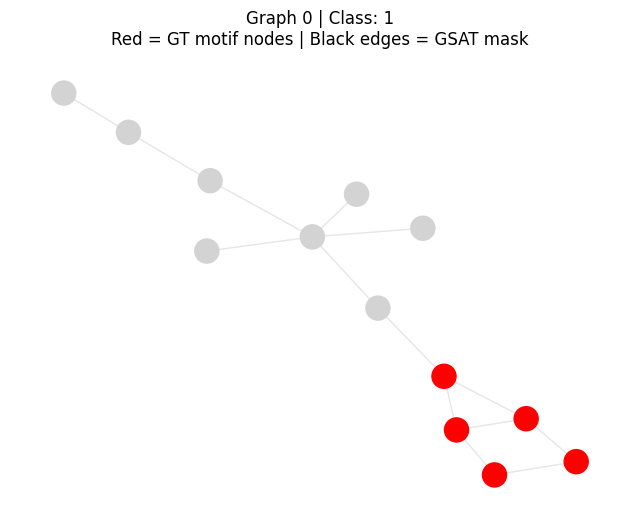

In [9]:
# -------------------------
# Visualize a single explanation
# -------------------------
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_explanation(model, dataset, idx=0, threshold=0.5):
    data = dataset[idx].to(DEVICE)
    model.eval()
    with torch.no_grad():
        _, mask, _ = model(data, training=False)

    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G, seed=42)

    # Ground-truth node colors
    if hasattr(data, "node_mask"):
        gt_mask = data.node_mask.cpu().numpy()
    elif hasattr(data, "explanation_mask"):
        gt_mask = data.explanation_mask.cpu().numpy()
    else:
        gt_mask = np.zeros(data.num_nodes)

    node_colors = ["red" if m == 1 else "lightgrey" for m in gt_mask]

    row, col = data.edge_index.cpu().numpy()
    mask_np = mask.detach().cpu().numpy()
    important_edges = []
    scaffold_edges = []

    for i in range(len(row)):
        u, v = row[i], col[i]
        if mask_np[i] > threshold:
            important_edges.append((u, v))
        else:
            scaffold_edges.append((u, v))

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300)
    nx.draw_networkx_edges(G, pos, edgelist=scaffold_edges, alpha=0.1, edge_color="grey")
    nx.draw_networkx_edges(G, pos, edgelist=important_edges, width=2.0, edge_color="black")

    plt.title(
        f"Graph {idx} | Class: {int(data.y.item())}\n"
        "Red = GT motif nodes | Black edges = GSAT mask"
    )
    plt.axis("off")
    plt.show()

# Visualize one test graph
visualize_explanation(model, test_dataset, idx=0)

In [11]:
# -------------------------
# 5-Seed Evaluation (Accuracy / Node AUROC / Node Jaccard)
# -------------------------
from copy import deepcopy
from sklearn.metrics import roc_auc_score
from bcosgnn.explain import explain

SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100
EARLY_STOP_PATIENCE = 25
BATCH_SIZE = 128
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7
INFO_LOSS_COEF = 3.0

class BackboneWrapper(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x, edge_index, batch):
        return self.backbone(x, edge_index, edge_weight=None, batch=batch)


def train_gsat_one_seed(seed: int):
    set_seed(seed)

    indices = np.arange(len(dataset_list))
    np.random.shuffle(indices)

    n = len(indices)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train_idx = indices[:n_train]
    val_idx = indices[n_train : n_train + n_val]
    test_idx = indices[n_train + n_val :]

    train_dataset = [dataset_list[i] for i in train_idx]
    val_dataset = [dataset_list[i] for i in val_idx]
    test_dataset = [dataset_list[i] for i in test_idx]

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    backbone = BcosGINBackbone(
        in_dim=in_dim,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        b=2.0,
        max_out=1,
        drop_ratio=0.5,
    )

    model = GSAT(
        backbone=backbone,
        in_channels=in_dim,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)

        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            logits, _, mask_logits = model(batch, training=True)
            loss, _, _ = gsat_loss(
                logits,
                batch.y.view(-1).to(torch.long),
                mask_logits,
                r=R_PRIOR,
                pred_loss_coef=1.0,
                info_loss_coef=INFO_LOSS_COEF,
            )
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                logits, _, _ = model(batch, training=False)
                criterion = nn.CrossEntropyLoss()
                val_loss += criterion(logits, batch.y.view(-1).to(torch.long)).item()

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, _, _ = model(data, training=False)
            pred = logits.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.num_graphs

    acc = correct / max(total, 1)

    # Explain metrics
    wrapper = BackboneWrapper(model.backbone).to(DEVICE)
    wrapper.eval()

    node_aurocs = []
    node_jaccards = []

    for data in test_dataset:
        data = data.to(DEVICE)

        if hasattr(data, "node_mask"):
            gt_mask = data.node_mask.detach().cpu().numpy().astype(int)
        elif hasattr(data, "explanation_mask"):
            gt_mask = data.explanation_mask.detach().cpu().numpy().astype(int)
        else:
            continue

        batch = torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE)
        with torch.enable_grad():
            contrib = explain(wrapper, data.x, data.edge_index, batch).detach()
        node_scores = contrib.sum(dim=1)

        if node_scores.max() > node_scores.min():
            node_scores = (node_scores - node_scores.min()) / (node_scores.max() - node_scores.min())
        else:
            node_scores = torch.zeros_like(node_scores)

        scores_np = node_scores.cpu().numpy()

        if len(np.unique(gt_mask)) > 1:
            node_aurocs.append(roc_auc_score(gt_mask, scores_np))

        k = int(gt_mask.sum())
        if k > 0:
            top_k_indices = np.argsort(scores_np)[-k:]
            pred_binary = np.zeros_like(scores_np)
            pred_binary[top_k_indices] = 1

            intersect = (pred_binary * gt_mask).sum()
            union = (pred_binary + gt_mask).clip(0, 1).sum()
            node_jaccards.append(intersect / (union + 1e-8))

    node_auc = float(np.mean(node_aurocs)) if node_aurocs else float("nan")
    node_jaccard = float(np.mean(node_jaccards)) if node_jaccards else float("nan")

    return acc, node_auc, node_jaccard


results_acc = []
results_auc = []
results_jacc = []

print("Running 5-seed GSAT evaluation...")
for seed in SEEDS:
    acc, auc, jacc = train_gsat_one_seed(seed)
    results_acc.append(acc)
    results_auc.append(auc)
    results_jacc.append(jacc)
    print(f"Seed {seed} -> Acc: {acc:.4f} | AUROC: {auc:.4f} | Jaccard: {jacc:.4f}")

print("=" * 60)
print("FINAL RESULTS (5 Seeds)")
print("=" * 60)
print(f"Accuracy:     {np.mean(results_acc):.4f} ± {np.std(results_acc):.4f}")
print(f"Node AUROC:   {np.mean(results_auc):.4f} ± {np.std(results_auc):.4f}")
print(f"Node Jaccard: {np.mean(results_jacc):.4f} ± {np.std(results_jacc):.4f}")

Running 5-seed GSAT evaluation...
Seed 0 -> Acc: 1.0000 | AUROC: 0.8043 | Jaccard: 0.5808
Seed 0 -> Acc: 1.0000 | AUROC: 0.8043 | Jaccard: 0.5808
Seed 1 -> Acc: 1.0000 | AUROC: 0.8501 | Jaccard: 0.6119
Seed 1 -> Acc: 1.0000 | AUROC: 0.8501 | Jaccard: 0.6119
Seed 2 -> Acc: 1.0000 | AUROC: 0.7973 | Jaccard: 0.5577
Seed 2 -> Acc: 1.0000 | AUROC: 0.7973 | Jaccard: 0.5577
Seed 3 -> Acc: 1.0000 | AUROC: 0.7550 | Jaccard: 0.5295
Seed 3 -> Acc: 1.0000 | AUROC: 0.7550 | Jaccard: 0.5295
Seed 4 -> Acc: 1.0000 | AUROC: 0.7831 | Jaccard: 0.5696
FINAL RESULTS (5 Seeds)
Accuracy:     1.0000 ± 0.0000
Node AUROC:   0.7980 ± 0.0311
Node Jaccard: 0.5699 ± 0.0271
Seed 4 -> Acc: 1.0000 | AUROC: 0.7831 | Jaccard: 0.5696
FINAL RESULTS (5 Seeds)
Accuracy:     1.0000 ± 0.0000
Node AUROC:   0.7980 ± 0.0311
Node Jaccard: 0.5699 ± 0.0271
